In [15]:
import os
import json
import pickle
import pathlib
import numpy as np
import scipy.interpolate as interp
import tqdm #looked cool

import torch
import torch.nn as nn

# https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset , tensors can be used in the dataloader , good stuff!!
from torch.utils.data import TensorDataset, DataLoader

<function tqdm.std.trange(*args, **kwargs)>

In [2]:
dir = r"/Volumes/ESSD/BatteryLife" if os.name == 'posix' else r"D:\BatteryLife" 
# Extracting the labels and ascociated file location containing the cycles, Tongji needed a fix since it has '-' replaced with '#' in the # JSON labels ## 
# To fix stanfords issue - appending '2' to the pkl files and the json entries 
stanford_2_dir = os.path.join(dir,'Stanford_2') 
standford_2_list = os.listdir(stanford_2_dir) 



print(standford_2_list[0][0:10])

if standford_2_list[0][0:10] == 'Stanford_N':
    for file in standford_2_list:
         new_name = file[0:9]+'2_'+ file[9:]
         try:
             os.rename(os.path.join(stanford_2_dir,file),os.path.join(stanford_2_dir,new_name))
         except:
             print("Probably already sorted")
             break






Stanford_2


In [9]:



##Since each json file contains labels with the same folder of pickles, updated desgin now has an array with ascociated folder loc too (not size efficent but that dosent matter)
def get_dict(labels_dir):
    dict_labels = {}
    content = os.listdir(labels_dir)
    folder_locs = []
  
    for f in content:
        if f.startswith("._") or f.startswith(".DS_Store"):
            continue
        with open(os.path.join(labels_dir, f), 'r') as file:
            data = json.load(file)
            if 'Tongji' in f:
               temp_dict = {}
               for k, v in data.items():
                    k_new = k.replace("#", "-")
                    temp_dict.update({k_new:v})
               data = temp_dict   
            if 'Stanford_2' in f:
               temp_dict = {}
               for k, v in data.items():
                    k_new = k.replace("Stanford_Nova", "Stanford_2_Nova")
                    temp_dict.update({k_new:v})
               data = temp_dict 
            it = next(pathlib.Path(dir).rglob(list(data.keys())[0])) #Method to get just the first files location for a givben pkl file, 
            temp = list(dict.fromkeys(list(data.keys())))
            folder_locs.extend([os.path.split(it)[0] for x in range(len(temp))])  #https://www.geeksforgeeks.org/python/python-get-unique-values-list/
            dict_labels.update(data)
            
    k = list(dict_labels.keys())
    v = list(dict_labels.values())
    folder = folder_locs
    return k, v, folder


## Returns asociated file(label_path) and labels(soh) and folder locations * files 
## Issues found that some pkl files contained duplicate keys, seems STANDFAORD_2 NOVA has same keys as standford !

labels_path = os.path.join(dir, "Life labels")
cycles_file, soh, file_dir = get_dict(labels_path)
print(f"Found {len(soh)} labels, and {len(cycles_file)} keys/files")
print(soh)
print(cycles_file)
print(file_dir)

Found 1246 labels, and 1246 keys/files
[107, 105, 176, 161, 189, 123, 164, 104, 792, 980, 1233, 1272, 1352, 1260, 1267, 1283, 1241, 1243, 1169, 1253, 1410, 1318, 1301, 1260, 997, 993, 986, 568, 519, 538, 487, 448, 473, 590, 518, 739, 534, 534, 579, 829, 266, 228, 255, 246, 263, 234, 262, 257, 259, 231, 263, 239, 247, 218, 1760, 1179, 2116, 2230, 2033, 1975, 1421, 1901, 2344, 2755, 2023, 1938, 2088, 2106, 1981, 2261, 2359, 1747, 1726, 1907, 1946, 1531, 1821, 1441, 1742, 1779, 1722, 2575, 2353, 2100, 2189, 2538, 2436, 1667, 1600, 2025, 1793, 1549, 2569, 1869, 1164, 2080, 1420, 2278, 1450, 1490, 1726, 2255, 1318, 1432, 2272, 1972, 1752, 2768, 2574, 1528, 1911, 2764, 2377, 1545, 1698, 1382, 2583, 2412, 1338, 1995, 1812, 2716, 2338, 2542, 1634, 1829, 1621, 1849, 1810, 2061, 1542, 735, 1667, 817, 1031, 779, 428, 1500, 297, 1500, 937, 448, 607, 906, 466, 614, 466, 1567, 250, 1593, 1166, 1220, 658, 3713, 665, 3211, 134, 1269, 1463, 715, 3936, 593, 653, 393, 2646, 262, 2042, 419, 444, 358, 553,

In [ ]:
os.path.basename(dir)
my_dict = {'name': 2}
my_dict.keys()

<method-wrapper '__iter__' of dict_keys object at 0x000002479B938790>

In [111]:
t = pathlib.Path(dir).rglob('*.pkl')
for i,v in enumerate(t):
    print(f"{i} : {v} : {os.path.split(v)[0]} : {os.path.basename(os.path.split(v)[0])}")
print(next(iter(t)))

0 : D:\BatteryLife\CALB\CALB_0_B188.pkl : D:\BatteryLife\CALB : CALB
1 : D:\BatteryLife\CALB\CALB_25_T25-1.pkl : D:\BatteryLife\CALB : CALB
2 : D:\BatteryLife\CALB\CALB_35_B247.pkl : D:\BatteryLife\CALB : CALB
3 : D:\BatteryLife\CALB\CALB_45_B253.pkl : D:\BatteryLife\CALB : CALB
4 : D:\BatteryLife\CALB\CALB_45_B255.pkl : D:\BatteryLife\CALB : CALB
5 : D:\BatteryLife\CALB\CALB_25_T25-2.pkl : D:\BatteryLife\CALB : CALB
6 : D:\BatteryLife\CALB\CALB_45_B256.pkl : D:\BatteryLife\CALB : CALB
7 : D:\BatteryLife\CALB\CALB_35_B250.pkl : D:\BatteryLife\CALB : CALB
8 : D:\BatteryLife\CALB\CALB_35_B173.pkl : D:\BatteryLife\CALB : CALB
9 : D:\BatteryLife\CALB\CALB_35_B229.pkl : D:\BatteryLife\CALB : CALB
10 : D:\BatteryLife\CALB\CALB_35_B228.pkl : D:\BatteryLife\CALB : CALB
11 : D:\BatteryLife\CALB\CALB_35_B224.pkl : D:\BatteryLife\CALB : CALB
12 : D:\BatteryLife\CALB\CALB_35_B227.pkl : D:\BatteryLife\CALB : CALB
13 : D:\BatteryLife\CALB\CALB_35_B248.pkl : D:\BatteryLife\CALB : CALB
14 : D:\Battery

StopIteration: 

In [ ]:
# Used to get the total number of labels for trainig (by summing all entries in every json file)
def get_length(dir):
    content = os.listdir(dir)
    length = 0
    for f in content:
        if f.startswith("._") or f.startswith(".DS_Store"):
            continue
        with open(os.path.join(dir, f), 'r') as file:
            data = json.load(file)
            length += len(data)
    return length


In [15]:
content = os.listdir(dir)
print(f"###### \n ---- Content ---- ({content}) \n######")
folders = [f for f in content if os.path.isdir(os.path.join(dir, f)) and (f != "Life labels" and f != "READMEs") and not f.startswith("._") and not f.startswith(".DS_Store")]
pkl_files = [[] for _ in folders]
for i, folder in enumerate(folders) :
    folder_path = os.path.join(dir, folder)
    for file in os.listdir(folder_path):
        if file.endswith('.pkl'):
            pkl_files[i].append(file)
print(len(pkl_files))

###### 
 ---- Content ---- (['CALB', 'CALCE', 'HNEI', 'HUST', 'ISU_ILCC', 'Life labels', 'MATR', 'MICH', 'MICH_EXP', 'NA-ion', 'README.md', 'READMEs', 'RWTH', 'SDU', 'SNL', 'Stanford', 'Stanford_2', 'Tongji', 'UL_PUR', 'XJTU', 'ZN-coin', '.DS_Store', '._.DS_Store', '._README.md']) 
######
18


In [ ]:
import numpy as np
import scipy.interpolate as interp

def get_cycle_data(data, cycle_format):
    
    arr_total = np.zeros((cycle_format, 4, 300))
    
    for i in range(cycle_format):

        raw_time = np.array(data['cycle_data'][i]['time_in_s'])
        scaled_time = raw_time - raw_time[0]
        raw_current = np.array(data['cycle_data'][i]['current_in_A'])
        raw_voltage = np.array(data['cycle_data'][i]['voltage_in_V'])
        dt = np.diff(scaled_time)
        avg_current = 0.5 * (raw_current[1:] + raw_current[:-1])   # Adds nect time step onto previous (original + sited_by_one)
        cumulative_charge = np.concatenate(([0], np.cumsum(avg_current * dt) )) #My method shifts to right, so needed to add 0 at the start  
        
        capacity_Ah = cumulative_charge / 3600.0

        ## Some of the cycles I saw had starting in charging and others where starting in dishcharging, which mean the capacity values would be nonsesical
        ## thus checks are done below

        # If index of starting to charge is higher (after discharge), the chances are its discharging from 100% SoC first, so deduct peak capacity intergral from running intergral
        idx_charge = np.where((raw_current) > 0.1)[0]
        idx_discharge = np.where((raw_current) < -0.1)[0]

        if (len(idx_charge) == 0) or (len(idx_discharge) == 0):
            pass #do nothing, could be some better logic but left as is for now
        else:
            if idx_charge[0] > idx_discharge[0]: 
                capacity_Ah = np.abs(capacity_Ah.min()) + capacity_Ah

        t_new = np.linspace(0, scaled_time[-1], num=300)
        f_current = interp.interp1d(scaled_time, raw_current, kind='linear')
        f_voltage = interp.interp1d(scaled_time, raw_voltage, kind='linear')
        f_capacity = interp.interp1d(scaled_time, capacity_Ah, kind='linear')
        
        current_interpolated = f_current(t_new) / data['nominal_capacity_in_Ah']
        
        voltage_interpolated = f_voltage(t_new) / data['max_voltage_limit_in_V']
        
        capacity_interpolated = f_capacity(t_new) / data['nominal_capacity_in_Ah']
        
        size_channel = np.full(300, data['nominal_capacity_in_Ah'])
        
        arr_total[i] = np.stack(
            (current_interpolated,
             voltage_interpolated,
             capacity_interpolated,
             size_channel), 
            axis=0
        )
    
    return arr_total


In [13]:
import numpy as np
arr = np.array([2, 20,3,7, 8, 3, 10,-51,1])
idx = np.where(arr >5)[0]
print(idx)
print(np.abs(arr.min()))
print("Even elements:", arr[idx])

[1 3 4 6]
51
Even elements: [20  7  8 10]


In [7]:
test = np.array([1,2,3,4,5,6,7,8,9])
test[1:] + test[:-1]

array([ 3,  5,  7,  9, 11, 13, 15, 17])

In [ ]:

local_save_dir = "./processed_tensrs" 
os.makedirs(local_save_dir, exist_ok=True)

x_path = os.path.join(local_save_dir, "X_features.pt")
y_path = os.path.join(local_save_dir, "y_labels.pt")

if os.path.exists(x_path) and os.path.exists(y_path):
    print("Loading into ram (already exits)")
    X_tensor = torch.load(x_path)
    y_tensor = torch.load(y_path)
    print("Done")

else:
    print("Tensors not found, creating...")

    all_features = []
    all_labels = []

    # Loop through all files and extract the features
    for idx in tqdm.trange(len(soh), desc="Loadibg in the files"):
        try:
            with open(os.path.join(file_dir[idx], cycles_file[idx]), 'rb') as file:
             data = pickle.load(file)
             prev_file = file_dir[idx]
        except FileNotFoundError:
           print(f"File: {cycles_file[idx]} not found, skipping")
           continue
        features = get_cycle_data(data, cycle_format=1)
        all_features.append(features)
        all_labels.append(soh[idx])

    X_tensor = torch.tensor(np.array(all_features), dtype=torch.float32)
    y_tensor = torch.tensor(np.array(all_labels), dtype=torch.float32)

    torch.save(X_tensor, x_path)
    torch.save(y_tensor, y_path)
    
    print(f"Saved tensors to {local_save_dir}!")

print(f"Total Features Shape: {X_tensor.shape}")

 # --- NEW: ONLY GLOBALLY NORMALIZE THE 4TH CHANNEL (Capacity Scale) ---
    # Find the maximum nominal capacity across all batteries in the dataset
max_dataset_capacity = X_tensor[:, 0, 3, :].max() 
    
    # Divide ONLY the 4th channel by this maximum value
X_tensor[:, 0, 3, :] = X_tensor[:, 0, 3, :] / max_dataset_capacity
print(f"Added absolute scale channel! Max capacity was {max_dataset_capacity:.2f} Ah")
    # ---------------------------------------------------------------------

    # Save them locally for next time!
    

# --- NORMALIZATION ---
# Find the maximum cycle life in your dataset
y_max = y_tensor.max()
print(f"Max cycle life in dataset: {y_max.item()} cycles")

# Scale all targets to be between 0 and 1
y_tensor_normalized = y_tensor / y_max

# Create the dataset using the NORMALIZED labels
dataset = TensorDataset(X_tensor, y_tensor_normalized)
print(f"Size of dataset: {len(dataset)}")

# Safely split data (1000 for training, the rest for validation)
train_size = 1050
val_size = len(dataset) - train_size
train_data, val_data = torch.utils.data.random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_data, batch_size=30, shuffle=True, num_workers=0)
validation_loader = DataLoader(val_data, batch_size=30, shuffle=False, num_workers=0)


Tensors not found, creating...


Loadibg in the files:  82%|████████▏ | 1021/1246 [05:06<00:20, 11.20it/s]

File: MICH_11C_pouch_NMC_-5C_0-100_0.2-1.5C.pkl not found, skipping


Loadibg in the files:  82%|████████▏ | 1025/1246 [05:06<00:17, 12.74it/s]

File: MICH_02C_pouch_NMC_-5C_0-100_0.2-0.2C.pkl not found, skipping
File: MICH_07R_pouch_NMC_25C_0-100_2-2C.pkl not found, skipping


...

File: MICH_06H_pouch_NMC_45C_0-100_1.5-1.5C.pkl not found, skipping
File: MICH_05C_pouch_NMC_-5C_0-100_1.5-1.5C.pkl not found, skipping


Loadibg in the files:  85%|████████▌ | 1061/1246 [05:09<00:12, 15.00it/s]

File: MICH_01R_pouch_NMC_25C_0-100_0.2-0.2C.pkl not found, skipping
File: MICH_03H_pouch_NMC_45C_0-100_0.2-0.2C.pkl not found, skipping


Loadibg in the files: 100%|██████████| 1246/1246 [06:48<00:00,  3.05it/s]

Added absolute scale channel! Max capacity was 58.00 Ah
Saved tensors to ./processed_tensrs!
Total Features Shape: torch.Size([1234, 1, 4, 300])
Max cycle life in dataset: 4999.0 cycles
Size of dataset: 1234


In [40]:
x_tensor = torch.rand(2,3,10)
y_tensor = torch.rand(2,1)
test=  TensorDataset(x_tensor,y_tensor)
out = next(iter(test))
print(out)

(tensor([[0.3009, 0.6247, 0.4890, 0.9076, 0.6847, 0.1359, 0.3916, 0.7308, 0.2424,
         0.3210],
        [0.0457, 0.9072, 0.3962, 0.6104, 0.2005, 0.4169, 0.8703, 0.3346, 0.0883,
         0.9616],
        [0.2815, 0.2975, 0.0571, 0.9440, 0.2051, 0.6647, 0.1564, 0.4544, 0.7449,
         0.0529]]), tensor([0.7082]))


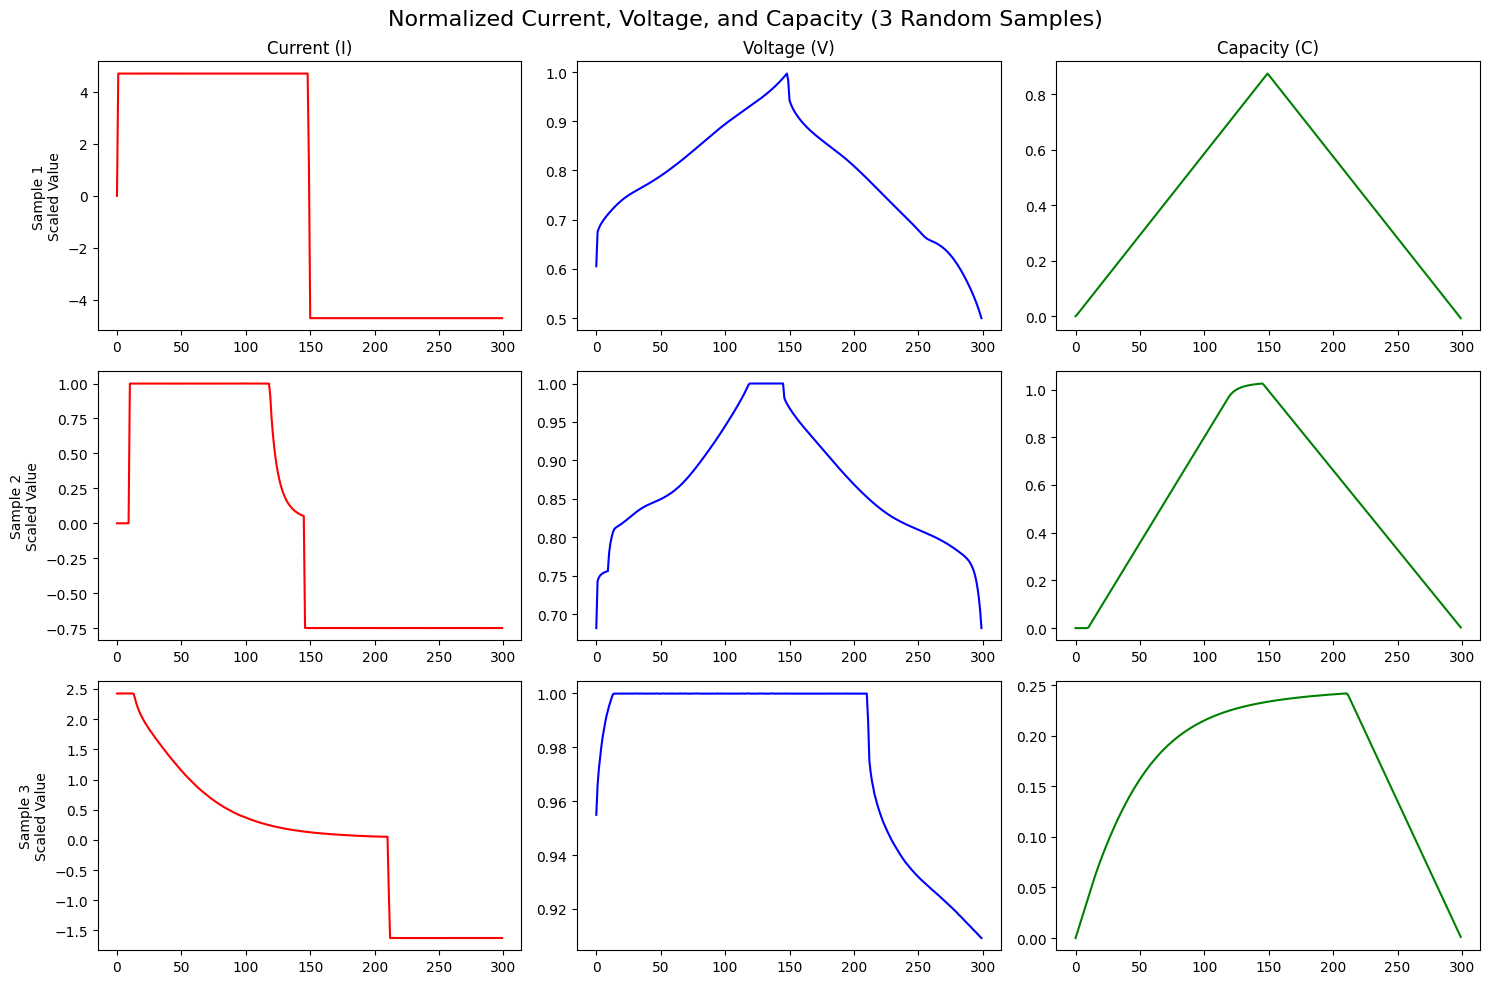

In [44]:
import matplotlib.pyplot as plt
import random

## Used gemini here as i really lost patientce for grpahing

# Grab a single batch of data
train_features, train_labels = next(iter(train_loader))

# Set up the plot to show 3 random batteries to see if they are squashed
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
fig.suptitle("Normalized Current, Voltage, and Capacity (3 Random Samples)", fontsize=16)

for i in range(3):
    # Pick a random battery from this batch
    idx = random.randint(0, train_features.size(0) - 1)
    
    # Squeeze out the channel dim -> Shape: [3, 300]
    sample = train_features[idx].squeeze(0).numpy() 
    
    current = sample[0]
    voltage = sample[1]
    capacity = sample[2]
    
    time_steps = range(300)
    
    # Plot Current
    axes[i, 0].plot(time_steps, current, color='red')
    axes[i, 0].set_ylabel(f"Sample {i+1}\nScaled Value")
    if i == 0: axes[i, 0].set_title("Current (I)")
    
    # Plot Voltage
    axes[i, 1].plot(time_steps, voltage, color='blue')
    if i == 0: axes[i, 1].set_title("Voltage (V)")
    
    # Plot Capacity
    axes[i, 2].plot(time_steps, capacity, color='green')
    if i == 0: axes[i, 2].set_title("Capacity (C)")

plt.tight_layout()
plt.show()

In [34]:
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels}")
print(f"Squeezed shape: {train_features.squeeze(1).shape}")

Feature batch shape: torch.Size([64, 1, 4, 300])
Labels batch shape: tensor([0.1596, 0.0744, 0.0480, 0.0928, 0.1582, 0.1218, 0.0944, 0.1634, 0.1704,
        0.0286, 0.1622, 0.4409, 0.1364, 0.1298, 0.0214, 0.1196, 0.1194, 0.0662,
        0.1818, 0.4677, 0.0856, 0.0284, 0.0204, 0.4123, 0.1020, 0.2106, 0.0818,
        0.0814, 0.0370, 0.1742, 0.0916, 0.1028, 0.0230, 0.2034, 0.1330, 0.0534,
        0.1998, 0.0054, 0.1504, 0.0296, 0.0856, 0.2284, 0.1118, 0.1458, 0.3821,
        0.1242, 0.1542, 0.0846, 0.0828, 0.0980, 0.1328, 0.1696, 0.1066, 0.1050,
        0.3063, 0.1114, 0.0926, 0.0588, 0.2338, 0.1718, 0.1588, 0.0452, 0.5529,
        0.1710])
Squeezed shape: torch.Size([64, 4, 300])


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt # <--- Added for plotting

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}, gpu -> {torch.cuda.get_device_name(0) if torch.cuda.is_available() is True else 'N/A'}")
y_max = y_max.to(device)

class LSTMnetwork(nn.Module):
    def __init__(self, hidden_size=110, num_layers=4):
        super(LSTMnetwork, self).__init__()

        self.lstm = nn.LSTM(
            input_size=4,
            hidden_size=hidden_size, 
            num_layers=num_layers, 
            batch_first=True,
            dropout=0.2
        )
        self.out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = x.squeeze(1).permute(0, 2, 1) 
        _, (hidden_layers, _) = self.lstm(x)
        cycle_to_80_pred = self.out(hidden_layers[-1]) 

        return cycle_to_80_pred.flatten()

model = LSTMnetwork(hidden_size=95, num_layers=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
criterion = nn.MSELoss()
epochs = 15000

train_mae_history = []
val_mae_history = []

for epoch in range(epochs):

    model.train() 
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)    
        optimizer.zero_grad()
        
        preds = model(batch_x)   

        loss = criterion(preds, batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            preds_real = preds * y_max
            batch_y_real = batch_y * y_max
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)


    model.eval()
    val_loss = 0
    val_mae = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            preds_real = preds * y_max
            batch_y_real = batch_y * y_max
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)

    if epoch % 10 == 0:
        print(f"Epoch {epoch} ---", f"Training Error: {avg_train_mae:.1f} cycles ---", f"Validation Error: {avg_val_mae:.1f} cycles")

plt.figure()
plt.plot(train_mae_history, label='Training MAE', color='green', linewidth=2)
plt.plot(val_mae_history, label='Validation MAE', color='red', linewidth=2)

plt.title('LSTM: Cylcels to 80%% labels', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

Using cuda, gpu -> NVIDIA GeForce RTX 5080
Epoch 0 --- Training Error: 460.9 cycles --- Validation Error: 392.9 cycles
Epoch 10 --- Training Error: 378.1 cycles --- Validation Error: 349.5 cycles
Epoch 20 --- Training Error: 347.7 cycles --- Validation Error: 302.3 cycles
Epoch 30 --- Training Error: 367.6 cycles --- Validation Error: 356.4 cycles
Epoch 40 --- Training Error: 279.7 cycles --- Validation Error: 289.4 cycles
Epoch 50 --- Training Error: 311.5 cycles --- Validation Error: 258.3 cycles
Epoch 60 --- Training Error: 250.3 cycles --- Validation Error: 322.5 cycles
Epoch 70 --- Training Error: 227.2 cycles --- Validation Error: 267.4 cycles
Epoch 80 --- Training Error: 235.1 cycles --- Validation Error: 229.1 cycles
Epoch 90 --- Training Error: 213.1 cycles --- Validation Error: 242.4 cycles
Epoch 100 --- Training Error: 240.5 cycles --- Validation Error: 246.3 cycles
Epoch 110 --- Training Error: 199.5 cycles --- Validation Error: 183.6 cycles
Epoch 120 --- Training Error: 19

KeyboardInterrupt: 

: 

In [23]:
## BELOOW is from Gemini, got too curious of tensors before learning how to fully implament, seems to work tho!

import torch
import torch.nn as nn
import math
import matplotlib.pyplot as plt

# Device configuration
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device}")

# ==========================
# 1. POSITIONAL ENCODING
# ==========================
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create constant 'pe' matrix with values dependent on pos and i
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

# ==========================
# 2. TRANSFORMER NETWORK
# ==========================
class TransformerNetwork(nn.Module):
    def __init__(self, input_size=4, d_model=96, nhead=4, num_layers=4, dropout=0.2):
        super(TransformerNetwork, self).__init__()
        
        # 1. Convolutional Stem: Captures local slopes/trends
        self.conv_embedding = nn.Conv1d(in_channels=input_size, 
                                        out_channels=d_model, 
                                        kernel_size=5, 
                                        padding=2) 
        
        # 2. Positional Encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        
        # 3. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=d_model * 4, 
            dropout=dropout,
            batch_first=True,
            activation="gelu" 
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Output Head
        self.out = nn.Sequential(
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, 1)
        )

    def forward(self, x):
        x = x.squeeze(1) 
        x = self.conv_embedding(x) 
        x = x.permute(0, 2, 1)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x) 
        
        # Global Average Pooling
        x = torch.mean(x, dim=1) 
        pred = self.out(x)
        
        return pred.flatten()

# ==========================
# 3. SETUP 
# ==========================
model = TransformerNetwork(
    input_size=4,    # IMPORTANT: Updated to 4 to accept our new Scale channel
    d_model=152,      
    nhead=4,         
    num_layers=4,    
    dropout=0.3
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4) 
criterion = nn.MSELoss()

# ==========================
# 4. TRAINING & VALIDATION LOOP
# ==========================
epochs = 2000

train_mae_history = []
val_mae_history = []

for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() 
    train_loss = 0
    train_mae = 0

    for batch_x, batch_y in train_loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        preds = model(batch_x)   
        
        loss = criterion(preds, batch_y)
        loss.backward()
        
        # CRUCIAL FIX FOR TRANSFORMERS: Gradient Clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        train_loss += loss.item()

        with torch.no_grad():
            preds_real = preds * y_max
            batch_y_real = batch_y * y_max
            mae = torch.abs(preds_real - batch_y_real).mean()
            train_mae += mae.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_train_mae = train_mae / len(train_loader)
    train_mae_history.append(avg_train_mae)

    # --- VALIDATION PHASE ---
    model.eval() 
    val_loss = 0
    val_mae = 0

    with torch.no_grad():
        for batch_x, batch_y in validation_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            
            preds = model(batch_x)
            loss = criterion(preds, batch_y)
            val_loss += loss.item()
            
            preds_real = preds * y_max
            batch_y_real = batch_y * y_max
            mae = torch.abs(preds_real - batch_y_real).mean()
            val_mae += mae.item()

    avg_val_loss = val_loss / len(validation_loader)
    avg_val_mae = val_mae / len(validation_loader)
    val_mae_history.append(avg_val_mae)

    # Print every 10 epochs to keep the console clean
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"Epoch {epoch:04d} | Train Error: {avg_train_mae:.1f} cycles | Val Error: {avg_val_mae:.1f} cycles")

# ==========================
# 5. PLOT RESULTS
# ==========================
plt.figure(figsize=(10, 6))
plt.plot(train_mae_history, label='Training MAE', color='blue', linewidth=1.5)
plt.plot(val_mae_history, label='Validation MAE', color='orange', linewidth=1.5)

plt.title('Transformer Learning Curve: Cycle Life Prediction', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error (Cycles)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)
plt.tight_layout()

plt.show()

Using cuda
Epoch 0000 | Train Error: 592.6 cycles | Val Error: 408.0 cycles
Epoch 0010 | Train Error: 359.3 cycles | Val Error: 420.9 cycles
Epoch 0020 | Train Error: 298.3 cycles | Val Error: 394.9 cycles
Epoch 0030 | Train Error: 282.8 cycles | Val Error: 301.0 cycles
Epoch 0040 | Train Error: 266.8 cycles | Val Error: 278.4 cycles
Epoch 0050 | Train Error: 241.1 cycles | Val Error: 355.8 cycles
Epoch 0060 | Train Error: 243.3 cycles | Val Error: 273.6 cycles
Epoch 0070 | Train Error: 251.1 cycles | Val Error: 334.2 cycles
Epoch 0080 | Train Error: 243.2 cycles | Val Error: 301.0 cycles
Epoch 0090 | Train Error: 225.6 cycles | Val Error: 238.0 cycles
Epoch 0100 | Train Error: 229.0 cycles | Val Error: 278.5 cycles
Epoch 0110 | Train Error: 216.3 cycles | Val Error: 263.0 cycles
Epoch 0120 | Train Error: 218.0 cycles | Val Error: 258.9 cycles
Epoch 0130 | Train Error: 224.6 cycles | Val Error: 257.6 cycles
Epoch 0140 | Train Error: 211.9 cycles | Val Error: 229.4 cycles
Epoch 0150 | T

KeyboardInterrupt: 